# Advanced CNN Architectures

**Notebook 5** built LeNet from scratch: convolution, pooling, and a fully-connected head.  
That 5-layer network hit ~99% on MNIST — but real-world vision tasks (ImageNet: 1,000 classes, 1.2M images) demanded something much more powerful.

This notebook traces the **evolution of CNN architectures** through the ImageNet Large Scale Visual Recognition Challenge (ILSVRC), implementing each major breakthrough in PyTorch.

```
ImageNet top-5 error rate over time:

  2010  ──  28.2%  (traditional hand-crafted features)
  2012  ──  16.4%  AlexNet       ← deep CNN era begins
  2014  ──  7.3%   VGGNet        ← very deep, small filters
  2014  ──  6.7%   GoogLeNet     ← multi-scale (Inception)
  2015  ──  3.6%   ResNet        ← residual/skip connections
  2017  ──  2.3%   SENet         ← channel attention
  human ──  ~5.1%  (human-level performance surpassed in 2015)
```

---
**Topics covered**
1. The ImageNet challenge — why deeper networks matter
2. VGGNet — very deep networks with 3×3 filters
3. ResNet — skip connections and residual learning
4. Inception / GoogLeNet — multi-scale feature extraction
5. DenseNet — dense skip connections
6. MobileNet — depthwise separable convolutions for efficiency
7. Transfer learning — reusing pre-trained weights
8. Squeeze-and-Excitation (SE) blocks — channel attention
9. Architecture comparison — accuracy vs parameters vs speed
10. Summary and what comes next (ViT, ConvNeXt)

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from collections import OrderedDict

np.random.seed(42)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torchvision import datasets, transforms, models
    from torch.utils.data import DataLoader, random_split
    TORCH = True
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'PyTorch {torch.__version__} | device: {device}')
except ImportError:
    TORCH = False
    print('PyTorch not found — install with: pip install torch torchvision')
    print('Architecture diagrams and NumPy demos will still run.')

PyTorch 2.7.0 | device: cpu


## 1. The ImageNet Challenge — Why Deeper Networks?

The **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)** ran from 2010–2017 and became the benchmark that drove modern deep learning.

- **1.2 million** training images
- **1,000 categories** (from goldfish to volcano)
- Metric: **top-5 error** (model's top 5 predictions must include the correct class)

### Why does depth help?

| Network depth | Learned features |
|---|---|
| Layer 1–2 | Edges, colors, textures |
| Layer 3–4 | Shapes, patterns, parts |
| Layer 5–7 | Object parts (ears, wheels) |
| Layer 8+ | Object categories, semantic concepts |

Shallow networks can't build this **hierarchical feature representation**.  
The challenge: deeper networks are harder to train — gradients vanish as they propagate backward.

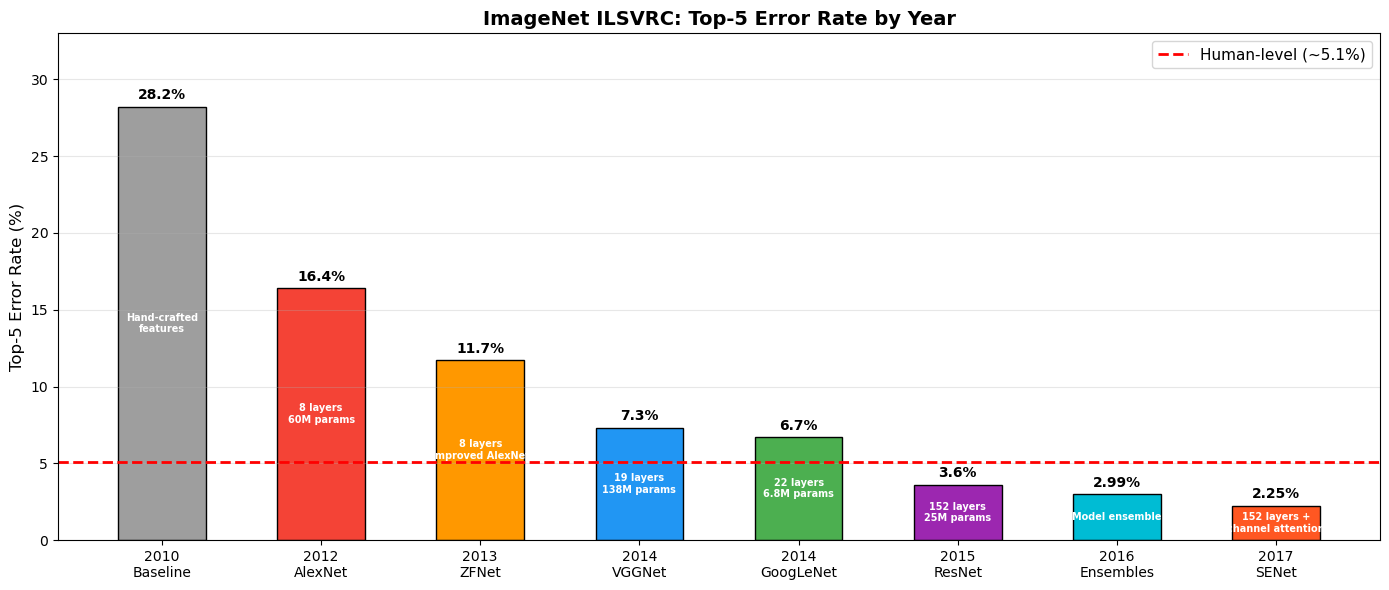

In [2]:
# ── ImageNet top-5 error rate history ────────────────────────────────────────
architectures = [
    ('2010\nBaseline',  28.2, '#9E9E9E', 'Hand-crafted\nfeatures'),
    ('2012\nAlexNet',   16.4, '#F44336', '8 layers\n60M params'),
    ('2013\nZFNet',     11.7, '#FF9800', '8 layers\n(improved AlexNet)'),
    ('2014\nVGGNet',     7.3, '#2196F3', '19 layers\n138M params'),
    ('2014\nGoogLeNet',  6.7, '#4CAF50', '22 layers\n6.8M params'),
    ('2015\nResNet',     3.6, '#9C27B0', '152 layers\n25M params'),
    ('2016\nEnsembles',  2.99,'#00BCD4', 'Model ensemble'),
    ('2017\nSENet',      2.25,'#FF5722', '152 layers +\nchannel attention'),
]

names  = [a[0] for a in architectures]
errors = [a[1] for a in architectures]
colors = [a[2] for a in architectures]
notes  = [a[3] for a in architectures]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(names, errors, color=colors, edgecolor='black', width=0.55)

# Human baseline
ax.axhline(5.1, color='red', linestyle='--', lw=2, label='Human-level (~5.1%)')

for bar, err, note in zip(bars, errors, notes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{err}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            note, ha='center', va='center', fontsize=7, color='white',
            fontweight='bold', wrap=True)

ax.set_ylabel('Top-5 Error Rate (%)', fontsize=12)
ax.set_title('ImageNet ILSVRC: Top-5 Error Rate by Year', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 33)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. VGGNet — Very Deep Networks with 3×3 Filters

**Oxford VGG group, 2014** — Karen Simonyan & Andrew Zisserman

### The Key Insight: Stack 3×3 Filters

A single **5×5** convolution has the same **receptive field** as two stacked **3×3** convolutions — but stacking two 3×3 layers has:
- **Fewer parameters**: 2×(3×3×C×C) = 18C² vs 5×5×C×C = 25C²
- **More non-linearity**: an extra ReLU between the two 3×3 layers

**Structure of a VGG Block**
- A standard VGG block consists of several consecutive Convolution layers followed by a Max-Pooling layer. A ReLU activation function is applied after each convolution layer.

```
One 5×5 filter:      Two stacked 3×3 filters:
┌─────────────┐      ┌─────────┐   ┌─────────┐
│  5 × 5 = 25 │  vs  │ 3×3 = 9 │ → │ 3×3 = 9 │
│    weights  │      └─────────┘   └─────────┘
└─────────────┘      Same receptive field, 28% fewer weights + extra ReLU
```

### VGG-16 Architecture
```
Input (3×224×224)
  Block 1: Conv(64,3×3)×2 → MaxPool  →  64×112×112
  Block 2: Conv(128,3×3)×2 → MaxPool → 128×56×56
  Block 3: Conv(256,3×3)×3 → MaxPool → 256×28×28
  Block 4: Conv(512,3×3)×3 → MaxPool → 512×14×14
  Block 5: Conv(512,3×3)×3 → MaxPool → 512×7×7
  Flatten → FC(4096) → FC(4096) → FC(1000) → Softmax
```
138 million parameters — most in the FC layers.

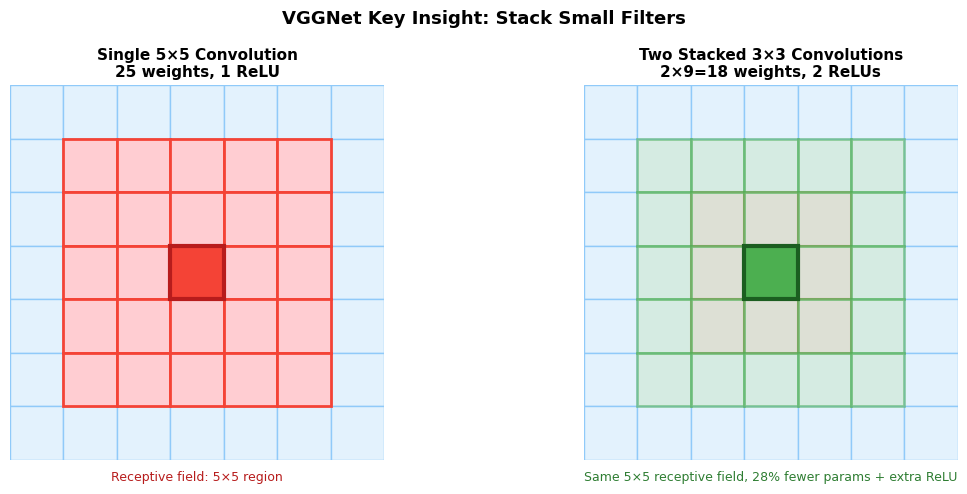

In [3]:
def receptive_field_demo():
    """Show that two 3×3 convs cover the same area as one 5×5."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    grid_size = 7
    for ax in axes:
        for i in range(grid_size):
            for j in range(grid_size):
                ax.add_patch(plt.Rectangle((j, grid_size-1-i), 1, 1,
                             fill=True, facecolor='#E3F2FD', edgecolor='#90CAF9', lw=1))
        ax.set_xlim(0, grid_size); ax.set_ylim(0, grid_size)
        ax.set_aspect('equal'); ax.axis('off')

    # Single 5×5
    ax = axes[0]
    for i in range(1, 6):
        for j in range(1, 6):
            ax.add_patch(plt.Rectangle((j, grid_size-1-i), 1, 1,
                         fill=True, facecolor='#FFCDD2', edgecolor='#F44336', lw=2))
    ax.add_patch(plt.Rectangle((3, grid_size-1-3), 1, 1,
                 fill=True, facecolor='#F44336', edgecolor='#B71C1C', lw=3))
    ax.set_title('Single 5×5 Convolution\n25 weights, 1 ReLU', fontweight='bold', fontsize=11)
    ax.text(3.5, -0.4, 'Receptive field: 5×5 region', ha='center', fontsize=9, color='#B71C1C')

    # Two 3×3
    ax = axes[1]
    # First 3×3 (darker red)
    for i in range(2, 5):
        for j in range(2, 5):
            ax.add_patch(plt.Rectangle((j, grid_size-1-i), 1, 1,
                         fill=True, facecolor='#FFCDD2', edgecolor='#F44336', lw=1.5, alpha=0.6))
    # Second 3×3 builds on that — expands to 5×5 effective
    for i in range(1, 6):
        for j in range(1, 6):
            ax.add_patch(plt.Rectangle((j, grid_size-1-i), 1, 1,
                         fill=True, facecolor='#C8E6C9', edgecolor='#4CAF50', lw=2, alpha=0.5))
    ax.add_patch(plt.Rectangle((3, grid_size-1-3), 1, 1,
                 fill=True, facecolor='#4CAF50', edgecolor='#1B5E20', lw=3))
    ax.set_title('Two Stacked 3×3 Convolutions\n2×9=18 weights, 2 ReLUs', fontweight='bold', fontsize=11)
    ax.text(3.5, -0.4, 'Same 5×5 receptive field, 28% fewer params + extra ReLU', ha='center', fontsize=9, color='#2E7D32')

    plt.suptitle('VGGNet Key Insight: Stack Small Filters', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

receptive_field_demo()

A single $3 \times 3$ filter has a receptive field of $3 \times 3$. If you stack another $3 \times 3$ filter on top, a neuron in the second layer sees a $3 \times 3$ area in the first layer. Since each cell in that area represents a $3 \times 3$ region in the input image, the total receptive field becomes $5 \times 5$.

When using three $3 \times 3$ layers, the ReLU activation function is applied three times. This allows the network to learn much more complex and discriminative features. In a single $7 \times 7$ layer, activation is applied only once.

In [4]:
if TORCH:

    class VGGBlock(nn.Module):
        """VGG-style block: N × [Conv(3×3) → BN → ReLU] → MaxPool."""
        def __init__(self, in_channels, out_channels, n_convs=2):
            super().__init__()
            layers = []
            for i in range(n_convs):
                layers += [
                    nn.Conv2d(in_channels if i == 0 else out_channels,
                              out_channels, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_channels),
                    nn.ReLU(inplace=True),
                ]
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            self.block = nn.Sequential(*layers)

        def forward(self, x):
            return self.block(x)


    class MiniVGG(nn.Module):
        """
        VGG-style network scaled down for CIFAR-10 (32×32 input).

        Architecture:
          Block1: Conv(32)×2 → Pool  →  32×16×16
          Block2: Conv(64)×2 → Pool  →  64×8×8
          Block3: Conv(128)×2 → Pool →  128×4×4
          Flatten → FC(256) → Dropout → FC(10)
        """
        def __init__(self, num_classes=10):
            super().__init__()
            self.features = nn.Sequential(
                VGGBlock(3,   32,  n_convs=2),  # 32×32 → 16×16
                VGGBlock(32,  64,  n_convs=2),  # 16×16 → 8×8
                VGGBlock(64,  128, n_convs=2),  # 8×8   → 4×4
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 4 * 4, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.5),
                nn.Linear(256, num_classes),
            )

        def forward(self, x):
            return self.classifier(self.features(x))


    vgg_model = MiniVGG()
    n_params = sum(p.numel() for p in vgg_model.parameters() if p.requires_grad)
    print('MiniVGG for CIFAR-10:')
    print(vgg_model)
    print(f'\nTotal trainable parameters: {n_params:,}')

    # Trace shapes
    print('\nForward pass shape trace:')
    x = torch.randn(1, 3, 32, 32)
    print(f'  Input: {tuple(x.shape)}')
    x = vgg_model.features[0](x); print(f'  After Block1 (Pool): {tuple(x.shape)}')
    x = vgg_model.features[1](x); print(f'  After Block2 (Pool): {tuple(x.shape)}')
    x = vgg_model.features[2](x); print(f'  After Block3 (Pool): {tuple(x.shape)}')
    x = vgg_model.classifier(x); print(f'  After Classifier:    {tuple(x.shape)}')

MiniVGG for CIFAR-10:
MiniVGG(
  (features): Sequential(
    (0): VGGBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): VGGBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

## 3. ResNet — Residual Learning & Skip Connections

**Microsoft Research, 2015** — Kaiming He et al. — Won ILSVRC 2015 with only **3.6% error**

### The Vanishing Gradient Problem

Going deeper than ~20 layers with standard architectures causes **training accuracy to degrade** — not just test accuracy.  
The culprit: gradients shrink exponentially as they travel backward through many layers.

### The Residual Block Solution

Instead of learning a mapping `H(x)`, each block learns the **residual** `F(x) = H(x) - x`, then adds the input back:

```
  Standard block:         Residual block:

  x ──► Conv ──► ReLU     x ──► Conv ──► BN ──► ReLU
        │                  │             │
        ▼         vs       │    Conv ──► BN     ┐ + x (identity shortcut)
       H(x)                └────────────────────┘
                                         │
                                        ReLU
                                         │
                                        H(x) = F(x) + x
```

**Why it works:**
- If the layers are not needed, `F(x) → 0` and the block becomes an **identity mapping** — easy to learn.
- Gradients flow directly through the shortcut connection — **no vanishing gradient**.
- Enabled training of **150+ layer networks**.

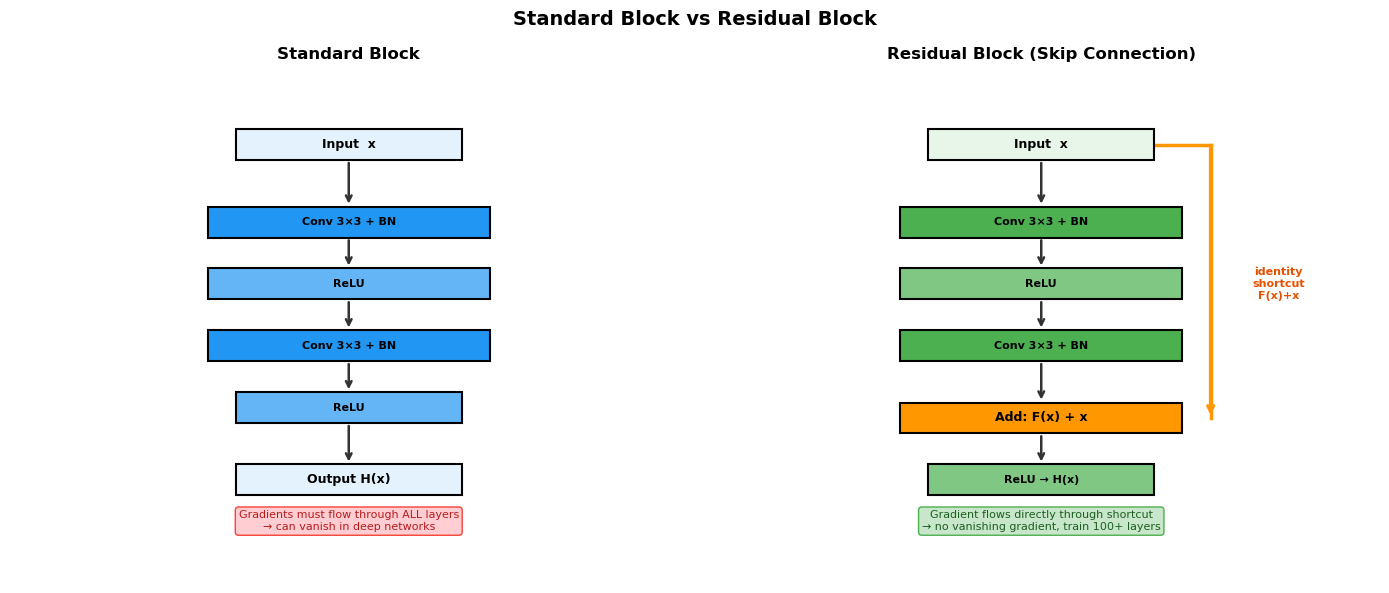

In [5]:
def draw_residual_block():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    def draw_box(ax, x, y, w, h, label, color, fontsize=9):
        rect = plt.Rectangle((x - w/2, y - h/2), w, h,
                               facecolor=color, edgecolor='black', lw=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
                fontweight='bold', zorder=4)

    def arrow(ax, x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=1.8), zorder=2)

    for ax in axes:
        ax.set_xlim(0, 6); ax.set_ylim(0, 10)
        ax.axis('off')

    # ── Standard block ───────────────────────────────────────────────────────
    ax = axes[0]
    ax.set_title('Standard Block', fontweight='bold', fontsize=12)
    draw_box(ax, 3, 8.5, 2, 0.6, 'Input  x', '#E3F2FD')
    draw_box(ax, 3, 7.0, 2.5, 0.6, 'Conv 3×3 + BN', '#2196F3', 8)
    draw_box(ax, 3, 5.8, 2.5, 0.6, 'ReLU', '#64B5F6', 8)
    draw_box(ax, 3, 4.6, 2.5, 0.6, 'Conv 3×3 + BN', '#2196F3', 8)
    draw_box(ax, 3, 3.4, 2, 0.6, 'ReLU', '#64B5F6', 8)
    draw_box(ax, 3, 2.0, 2, 0.6, 'Output H(x)', '#E3F2FD')
    for (y1, y2) in [(8.2,7.3),(6.7,6.1),(5.5,4.9),(4.3,3.7),(3.1,2.3)]:
        arrow(ax, 3, y1, 3, y2)
    ax.text(3, 1.2, 'Gradients must flow through ALL layers\n→ can vanish in deep networks',
            ha='center', va='center', fontsize=8, color='#B71C1C',
            bbox=dict(facecolor='#FFCDD2', edgecolor='#F44336', boxstyle='round,pad=0.3'))

    # ── Residual block ───────────────────────────────────────────────────────
    ax = axes[1]
    ax.set_title('Residual Block (Skip Connection)', fontweight='bold', fontsize=12)
    draw_box(ax, 3, 8.5, 2, 0.6, 'Input  x', '#E8F5E9')
    draw_box(ax, 3, 7.0, 2.5, 0.6, 'Conv 3×3 + BN', '#4CAF50', 8)
    draw_box(ax, 3, 5.8, 2.5, 0.6, 'ReLU', '#81C784', 8)
    draw_box(ax, 3, 4.6, 2.5, 0.6, 'Conv 3×3 + BN', '#4CAF50', 8)
    draw_box(ax, 3, 3.2, 2.5, 0.6, 'Add: F(x) + x', '#FF9800', 9)
    draw_box(ax, 3, 2.0, 2, 0.6, 'ReLU → H(x)', '#81C784', 8)
    for (y1, y2) in [(8.2,7.3),(6.7,6.1),(5.5,4.9),(4.3,3.5),(2.9,2.3)]:
        arrow(ax, 3, y1, 3, y2)
    # Skip connection
    ax.annotate('', xy=(4.5, 3.2), xytext=(4.5, 8.5),
                arrowprops=dict(arrowstyle='->', color='#FF9800', lw=2.5,
                                connectionstyle='arc3,rad=0.0'), zorder=2)
    ax.plot([4.0, 4.5], [8.5, 8.5], color='#FF9800', lw=2.5)
    ax.plot([4.5, 4.5], [8.5, 3.2], color='#FF9800', lw=2.5)
    ax.text(5.1, 5.8, 'identity\nshortcut\nF(x)+x', ha='center', va='center',
            fontsize=8, color='#E65100', fontweight='bold')
    ax.text(3, 1.2, 'Gradient flows directly through shortcut\n→ no vanishing gradient, train 100+ layers',
            ha='center', va='center', fontsize=8, color='#1B5E20',
            bbox=dict(facecolor='#C8E6C9', edgecolor='#4CAF50', boxstyle='round,pad=0.3'))

    plt.suptitle('Standard Block vs Residual Block', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_residual_block()

In [6]:
if TORCH:

    class ResidualBlock(nn.Module):
        """
        Basic ResNet residual block: two 3×3 convs with a skip connection.
        A projection shortcut is used when channels or spatial size change.
        """
        expansion = 1

        def __init__(self, in_channels, out_channels, stride=1):
            super().__init__()
            self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                                   stride=stride, padding=1, bias=False)
            self.bn1   = nn.BatchNorm2d(out_channels)

            self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                                   stride=1, padding=1, bias=False)
            self.bn2   = nn.BatchNorm2d(out_channels)

            # If channels or spatial size change, we need to project the shortcut
            self.shortcut = nn.Sequential()
            if stride != 1 or in_channels != out_channels:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                    nn.BatchNorm2d(out_channels)
                )

        def forward(self, x):
            residual = self.shortcut(x)          # identity or projected

            out = F.relu(self.bn1(self.conv1(x)))
            out = self.bn2(self.conv2(out))

            out = F.relu(out + residual)         # ← the key addition
            return out


    class ResNet(nn.Module):
        """
        ResNet scaled for CIFAR-10 (32×32).

        Architecture:
          Stem:    Conv(64) → BN → ReLU            32×32→32×32
          Layer1:  2× ResidualBlock(64→64)          32×32
          Layer2:  2× ResidualBlock(64→128, s=2)    16×16
          Layer3:  2× ResidualBlock(128→256, s=2)   8×8
          GlobalAvgPool → FC(256→num_classes)
        """
        def __init__(self, num_classes=10):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv2d(3, 64, 3, padding=1, bias=False),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True)
            )
            self.layer1 = self._make_layer(64,  64,  2, stride=1)
            self.layer2 = self._make_layer(64,  128, 2, stride=2)
            self.layer3 = self._make_layer(128, 256, 2, stride=2)
            self.pool   = nn.AdaptiveAvgPool2d(1)   # Global Average Pooling
            self.fc     = nn.Linear(256, num_classes)

        def _make_layer(self, in_ch, out_ch, n_blocks, stride):
            layers = [ResidualBlock(in_ch, out_ch, stride)]
            for _ in range(1, n_blocks):
                layers.append(ResidualBlock(out_ch, out_ch, 1))
            return nn.Sequential(*layers)

        def forward(self, x):
            x = self.stem(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)


    resnet = ResNet()
    n_params = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
    print(f'ResNet (CIFAR-10 version)')
    print(f'Total trainable parameters: {n_params:,}')

    # Trace shapes through the network
    x = torch.randn(2, 3, 32, 32)
    print('\nShape trace (batch=2):')
    print(f'  Input:   {tuple(x.shape)}')
    x = resnet.stem(x);   print(f'  Stem:    {tuple(x.shape)}')
    x = resnet.layer1(x); print(f'  Layer1:  {tuple(x.shape)}')
    x = resnet.layer2(x); print(f'  Layer2:  {tuple(x.shape)}')
    x = resnet.layer3(x); print(f'  Layer3:  {tuple(x.shape)}')
    x = resnet.pool(x).flatten(1); print(f'  After GAP: {tuple(x.shape)}')
    x = resnet.fc(x);    print(f'  Logits:  {tuple(x.shape)}')

ResNet (CIFAR-10 version)
Total trainable parameters: 2,777,674

Shape trace (batch=2):
  Input:   (2, 3, 32, 32)
  Stem:    (2, 64, 32, 32)
  Layer1:  (2, 64, 32, 32)
  Layer2:  (2, 128, 16, 16)
  Layer3:  (2, 256, 8, 8)
  After GAP: (2, 256)
  Logits:  (2, 10)


Summary
> ResNet solved the training bottleneck in deep networks using "skip connections" and became the foundation of modern AI.

### Bottleneck Block (ResNet-50/101/152)

>Standard ResNet blocks (Basic Blocks) consist of two $3 \times 3$ convolution layers. As the network gets deeper and the number of channels increases (e.g., 512 or 1024 channels), these $3 \times 3$ operations require significant computational power and memory.

For very deep networks, the **bottleneck** design reduces computation:
1×1 conv reduces channels → 3×3 conv (fewer channels) → 1×1 conv expands back.

```
  Standard block (ResNet-18/34):    Bottleneck block (ResNet-50+):

  [256ch] ─► Conv 3×3 (256)         [256ch] ─► Conv 1×1 (64)   ← reduce
           ─► BN, ReLU                       ─► Conv 3×3 (64)   ← process
           ─► Conv 3×3 (256)                 ─► Conv 1×1 (256)  ← expand
           ─► BN                             ─► BN
  [+x]    ─► ReLU                   [+x]    ─► ReLU

  Params: 2×(3×3×256×256) = 1.18M   Params: 64×64×9 + 2×64×256×1 = 69K
                                     17× fewer parameters!
```

> Using bottleneck blocks in a network of the same depth allows for learning more complex features with significantly fewer parameters. This enables the model to be trained faster and occupy less disk space.

In [7]:
if TORCH:

    class BottleneckBlock(nn.Module):
        """ResNet bottleneck: 1×1 reduce → 3×3 process → 1×1 expand."""
        expansion = 4

        def __init__(self, in_channels, mid_channels, stride=1):
            super().__init__()
            out_channels = mid_channels * self.expansion

            self.conv1 = nn.Conv2d(in_channels, mid_channels, 1, bias=False)
            self.bn1   = nn.BatchNorm2d(mid_channels)

            self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3,
                                   stride=stride, padding=1, bias=False)
            self.bn2   = nn.BatchNorm2d(mid_channels)

            self.conv3 = nn.Conv2d(mid_channels, out_channels, 1, bias=False)
            self.bn3   = nn.BatchNorm2d(out_channels)

            self.shortcut = nn.Sequential()
            if stride != 1 or in_channels != out_channels:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                    nn.BatchNorm2d(out_channels)
                )

        def forward(self, x):
            residual = self.shortcut(x)
            out = F.relu(self.bn1(self.conv1(x)))
            out = F.relu(self.bn2(self.conv2(out)))
            out = self.bn3(self.conv3(out))
            return F.relu(out + residual)


    # Compare parameter counts
    C = 256
    std_params    = 2 * (3*3*C*C) + 2*C          # 2× Conv3×3 + 2× BN
    bottle_mid    = C // 4
    bottle_params = (1*1*C*bottle_mid) + (3*3*bottle_mid*bottle_mid) + (1*1*bottle_mid*C) + 3*(C//4)

    print('Block parameter comparison (256 channels):')
    print(f'  Standard block (3×3, 3×3):          {std_params:>8,} params')
    print(f'  Bottleneck block (1×1, 3×3, 1×1):  {bottle_params:>8,} params')
    print(f'  Reduction factor: {std_params/bottle_params:.1f}×')

    basic = ResidualBlock(256, 256)
    bottleneck = BottleneckBlock(256, 64)
    p_basic = sum(p.numel() for p in basic.parameters())
    p_bottle = sum(p.numel() for p in bottleneck.parameters())
    print(f'\n  Actual PyTorch counts:')
    print(f'  Basic block:      {p_basic:,}')
    print(f'  Bottleneck block: {p_bottle:,}')
    print(f'  Ratio: {p_basic/p_bottle:.1f}×')

Block parameter comparison (256 channels):
  Standard block (3×3, 3×3):          1,180,160 params
  Bottleneck block (1×1, 3×3, 1×1):    69,824 params
  Reduction factor: 16.9×

  Actual PyTorch counts:
  Basic block:      1,180,672
  Bottleneck block: 70,400
  Ratio: 16.8×


## 4. Inception / GoogLeNet — Multi-Scale Feature Extraction

**Google, 2014** — Christian Szegedy et al.  

### The Core Problem
What's the **right filter size** for a given layer? Objects appear at different scales in images.  
A cat's eye might need a 3×3 filter while its body needs a 7×7 filter.

### The Inception Solution: Run Them All in Parallel

```
                      ┌──► 1×1 conv (96) ─────────────────────┐
                      │                                         │
                      ├──► 1×1 conv (16) ──► 3×3 conv (32) ───┤
 Input  ─── split ───┤                                         ├──► concat ──► Output
                      ├──► 1×1 conv (8)  ──► 5×5 conv (8) ────┤
                      │                                         │
                      └──► 3×3 MaxPool   ──► 1×1 conv (32) ───┘
```

- Different filter sizes run **in parallel** and are concatenated along the channel dimension
- **1×1 convolutions** (bottlenecks) before 3×3 and 5×5 reduce channels first → huge compute savings
- The network learns **which scale matters most** for each location

In [8]:
if TORCH:

    class InceptionModule(nn.Module):
        """
        Inception module with dimensionality reduction.

        Four parallel paths:
          1. 1×1 conv
          2. 1×1 reduce → 3×3 conv
          3. 1×1 reduce → 5×5 conv
          4. 3×3 MaxPool → 1×1 conv
        All outputs are concatenated along the channel dimension.
        """
        def __init__(self, in_ch, out_1x1, reduce_3x3, out_3x3,
                     reduce_5x5, out_5x5, out_pool):
            super().__init__()

            # Path 1: 1×1 conv
            self.branch1 = nn.Sequential(
                nn.Conv2d(in_ch, out_1x1, 1), nn.BatchNorm2d(out_1x1), nn.ReLU(inplace=True)
            )
            # Path 2: 1×1 reduce → 3×3
            self.branch2 = nn.Sequential(
                nn.Conv2d(in_ch, reduce_3x3, 1), nn.BatchNorm2d(reduce_3x3), nn.ReLU(inplace=True),
                nn.Conv2d(reduce_3x3, out_3x3, 3, padding=1), nn.BatchNorm2d(out_3x3), nn.ReLU(inplace=True)
            )
            # Path 3: 1×1 reduce → 5×5
            self.branch3 = nn.Sequential(
                nn.Conv2d(in_ch, reduce_5x5, 1), nn.BatchNorm2d(reduce_5x5), nn.ReLU(inplace=True),
                nn.Conv2d(reduce_5x5, out_5x5, 5, padding=2), nn.BatchNorm2d(out_5x5), nn.ReLU(inplace=True)
            )
            # Path 4: MaxPool → 1×1
            self.branch4 = nn.Sequential(
                nn.MaxPool2d(3, stride=1, padding=1),
                nn.Conv2d(in_ch, out_pool, 1), nn.BatchNorm2d(out_pool), nn.ReLU(inplace=True)
            )

            total_out = out_1x1 + out_3x3 + out_5x5 + out_pool
            self.total_out = total_out

        def forward(self, x):
            b1 = self.branch1(x)
            b2 = self.branch2(x)
            b3 = self.branch3(x)
            b4 = self.branch4(x)
            return torch.cat([b1, b2, b3, b4], dim=1)   # concat along channels


    class MiniInception(nn.Module):
        """Small Inception network for CIFAR-10."""
        def __init__(self, num_classes=10):
            super().__init__()
            self.stem = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            )
            # InceptionModule(in_ch, 1x1, r3, 3x3, r5, 5x5, pool)
            self.inc1 = InceptionModule(64,  32, 16, 32,  8,  16, 16)  # out=96
            self.inc2 = InceptionModule(96,  64, 32, 64, 16,  32, 32)  # out=192
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc   = nn.Linear(192, num_classes)

        def forward(self, x):
            x = self.stem(x)
            x = self.inc1(x)
            x = self.inc2(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)


    inception_model = MiniInception()
    n_params = sum(p.numel() for p in inception_model.parameters() if p.requires_grad)
    print(f'MiniInception — Parameters: {n_params:,}')

    x = torch.randn(2, 3, 32, 32)
    out = inception_model(x)
    print(f'Output shape: {tuple(out.shape)}')

    # Visualise the parallel branches
    x_stem = inception_model.stem(x)
    inc1 = inception_model.inc1
    b1 = inc1.branch1(x_stem)
    b2 = inc1.branch2(x_stem)
    b3 = inc1.branch3(x_stem)
    b4 = inc1.branch4(x_stem)
    concat = torch.cat([b1, b2, b3, b4], dim=1)

    print('\nInception Module — Branch shapes:')
    print(f'  Input:            {tuple(x_stem.shape)}')
    print(f'  Branch1 (1×1):    {tuple(b1.shape)}')
    print(f'  Branch2 (3×3):    {tuple(b2.shape)}')
    print(f'  Branch3 (5×5):    {tuple(b3.shape)}')
    print(f'  Branch4 (pool):   {tuple(b4.shape)}')
    print(f'  Concatenated:     {tuple(concat.shape)}')

MiniInception — Parameters: 80,066
Output shape: (2, 10)

Inception Module — Branch shapes:
  Input:            (2, 64, 32, 32)
  Branch1 (1×1):    (2, 32, 32, 32)
  Branch2 (3×3):    (2, 32, 32, 32)
  Branch3 (5×5):    (2, 16, 32, 32)
  Branch4 (pool):   (2, 16, 32, 32)
  Concatenated:     (2, 96, 32, 32)


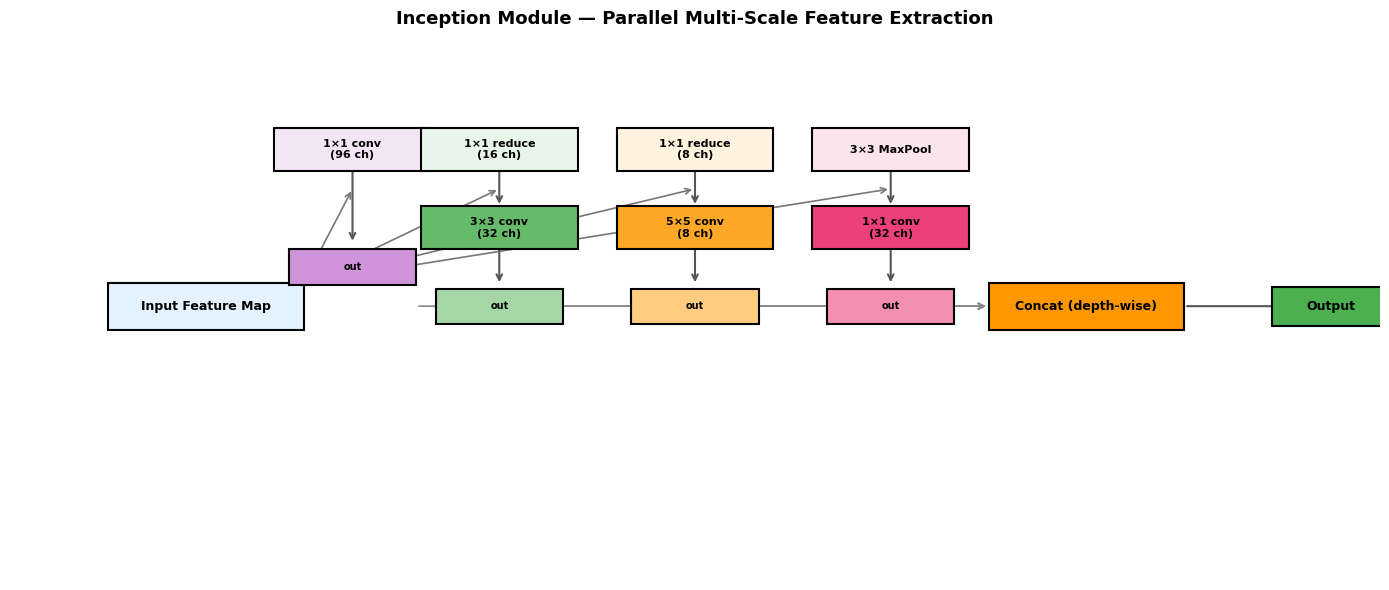

In [9]:
# Visualise the Inception module as a diagram
def draw_inception_module():
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_xlim(0, 14); ax.set_ylim(0, 7)
    ax.axis('off')

    def box(x, y, w, h, label, color, fontsize=8):
        rect = plt.Rectangle((x-w/2, y-h/2), w, h,
                               facecolor=color, edgecolor='black', lw=1.5, zorder=3)
        ax.add_patch(rect)
        ax.text(x, y, label, ha='center', va='center', fontsize=fontsize,
                fontweight='bold', zorder=4)

    def arr(x1, y1, x2, y2):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.5), zorder=2)

    box(2, 3.5, 2, 0.6, 'Input Feature Map', '#E3F2FD', 9)

    branches = [
        (3.5, '#F3E5F5', '#CE93D8', '1×1 conv\n(96 ch)', None, None, 6.5),
        (5.0, '#E8F5E9', '#A5D6A7', '1×1 reduce\n(16 ch)', '3×3 conv\n(32 ch)', '#66BB6A', 6.5),
        (7.0, '#FFF3E0', '#FFCC80', '1×1 reduce\n(8 ch)',  '5×5 conv\n(8 ch)',  '#FFA726', 6.5),
        (9.0, '#FCE4EC', '#F48FB1', '3×3 MaxPool', '1×1 conv\n(32 ch)', '#EC407A', 6.5),
    ]

    branch_xs = []
    for bx, c1, c2, lbl1, lbl2, c2c, out_x in branches:
        # Arrow from input to branch
        ax.annotate('', xy=(bx, 5.0), xytext=(3.0, 3.8),
                    arrowprops=dict(arrowstyle='->', color='#777', lw=1.2,
                                    connectionstyle=f'arc3,rad={0.0}'), zorder=1)
        box(bx, 5.5, 1.6, 0.55, lbl1, c1)
        if lbl2:
            arr(bx, 5.27, bx, 4.77)
            box(bx, 4.5, 1.6, 0.55, lbl2, c2c)
            arr(bx, 4.27, bx, 3.77)
            box(bx, 3.5, 1.3, 0.45, 'out', c2, 7)
        else:
            arr(bx, 5.27, bx, 4.3)
            box(bx, 4.0, 1.3, 0.45, 'out', c2, 7)
        branch_xs.append(bx)

    # Concatenation
    box(11, 3.5, 2, 0.6, 'Concat (depth-wise)', '#FF9800', 9)
    for bx in branch_xs:
        ax.annotate('', xy=(10.0, 3.5), xytext=(bx + 0.65, 3.5),
                    arrowprops=dict(arrowstyle='->', color='#888', lw=1.2), zorder=1)
    arr(12, 3.5, 13.2, 3.5)
    box(13.5, 3.5, 1.2, 0.5, 'Output', '#4CAF50', 9)

    ax.set_title('Inception Module — Parallel Multi-Scale Feature Extraction',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

draw_inception_module()

## 5. DenseNet — Dense Connections

**Cornell / Facebook, 2017** — Gao Huang et al.

### The Key Idea
ResNet adds layer output to input (`F(x) + x`).  
DenseNet **concatenates** each layer's output to **ALL subsequent layers**:

```
  ResNet (L=4):                     DenseNet (L=4):

  x₀ → H₁ → x₁                    x₀ ──────────────────────────────┐
       + x₀ ↑                       x₀,x₁ → H₂ → x₂               │
       → H₂ → x₂                    x₀,x₁,x₂ → H₃ → x₃            │ concat
       + x₁ ↑                       x₀,x₁,x₂,x₃ → H₄ → x₄         │
       ...                                                           ▼
                                    Each layer receives ALL prior feature maps
```

**Benefits:**
- **Feature reuse**: every layer directly accesses all prior features
- **Gradient highway**: gradients flow directly to all earlier layers
- **Compact**: surprisingly fewer parameters because channels don't duplicate

> In traditional networks, each layer receives information only from the previous layer. In DenseNet, each layer within a block receives inputs from all preceding layers and passes its own feature maps to all subsequent layers.

In [10]:
if TORCH:

    class DenseLayer(nn.Module):
        """Single dense layer: BN → ReLU → 1×1 → BN → ReLU → 3×3."""
        def __init__(self, in_channels, growth_rate):
            super().__init__()
            # Bottleneck: 1×1 reduces channels before 3×3
            bottleneck = 4 * growth_rate
            self.layer = nn.Sequential(
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, bottleneck, 1, bias=False),

                nn.BatchNorm2d(bottleneck),
                nn.ReLU(inplace=True),
                nn.Conv2d(bottleneck, growth_rate, 3, padding=1, bias=False),
            )

        def forward(self, x):
            new_features = self.layer(x)
            return torch.cat([x, new_features], dim=1)  # ← concatenate, not add


    class DenseBlock(nn.Module):
        """A block of L dense layers, each receiving all prior feature maps."""
        def __init__(self, in_channels, n_layers, growth_rate):
            super().__init__()
            self.layers = nn.ModuleList()
            ch = in_channels
            for _ in range(n_layers):
                self.layers.append(DenseLayer(ch, growth_rate))
                ch += growth_rate
            self.out_channels = ch

        def forward(self, x):
            for layer in self.layers:
                x = layer(x)
            return x


    class TransitionLayer(nn.Module):
        """Between dense blocks: BN → ReLU → 1×1 conv → AvgPool (halves spatial)."""
        def __init__(self, in_channels, compression=0.5):
            super().__init__()
            out_channels = int(in_channels * compression)
            self.layer = nn.Sequential(
                nn.BatchNorm2d(in_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.AvgPool2d(2, stride=2)
            )
            self.out_channels = out_channels

        def forward(self, x):
            return self.layer(x)


    class MiniDenseNet(nn.Module):
        """DenseNet scaled for CIFAR-10, growth_rate=12."""
        def __init__(self, growth_rate=12, num_classes=10):
            super().__init__()
            k = growth_rate
            init_ch = 2 * k

            self.stem = nn.Conv2d(3, init_ch, 3, padding=1, bias=False)

            db1 = DenseBlock(init_ch, n_layers=6, growth_rate=k)
            tr1 = TransitionLayer(db1.out_channels)

            db2 = DenseBlock(tr1.out_channels, n_layers=6, growth_rate=k)
            tr2 = TransitionLayer(db2.out_channels)

            db3 = DenseBlock(tr2.out_channels, n_layers=6, growth_rate=k)

            self.body = nn.Sequential(db1, tr1, db2, tr2, db3)
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.fc   = nn.Linear(db3.out_channels, num_classes)

        def forward(self, x):
            x = self.stem(x)
            x = self.body(x)
            x = self.pool(x).flatten(1)
            return self.fc(x)


    densenet = MiniDenseNet(growth_rate=12)
    n_params = sum(p.numel() for p in densenet.parameters() if p.requires_grad)
    print(f'MiniDenseNet (k=12) — Parameters: {n_params:,}')

    x = torch.randn(2, 3, 32, 32)
    out = densenet(x)
    print(f'Output shape: {tuple(out.shape)}')

    # Trace channels through the dense block
    k = 12
    init = 2 * k
    print(f'\nChannel growth through DenseBlock (k={k}, 6 layers):')
    ch = init
    for i in range(6):
        print(f'  After layer {i+1}: {ch} + {k} = {ch+k} channels')
        ch += k

MiniDenseNet (k=12) — Parameters: 175,858
Output shape: (2, 10)

Channel growth through DenseBlock (k=12, 6 layers):
  After layer 1: 24 + 12 = 36 channels
  After layer 2: 36 + 12 = 48 channels
  After layer 3: 48 + 12 = 60 channels
  After layer 4: 60 + 12 = 72 channels
  After layer 5: 72 + 12 = 84 channels
  After layer 6: 84 + 12 = 96 channels


## 6. MobileNet — Efficient CNNs for Edge Devices

**Google, 2017** — Andrew Howard et al.

### The Problem
VGG and ResNet are too large for mobile phones, IoT devices, or real-time inference.  
MobileNet introduces **depthwise separable convolutions** to slash computation.

### Depthwise Separable Convolution

Split a standard convolution into two steps:

```
Standard Conv (3×3, C_in=3, C_out=32):        Depthwise Separable:

  Apply 32 filters of shape (3, 3×3) at once    Step 1 — Depthwise Conv:
  Parameters: 32 × 3 × 3×3 = 864               Apply 1 filter per channel (3 filters of 3×3)
  FLOPs: 32 × 3 × 9 × H × W                   Parameters: 3 × 3×3 = 27
                                                 Output: (3, H, W)  — spatial features per channel

                                                 Step 2 — Pointwise Conv (1×1):
                                                 Combine channels: 32 filters of shape (3, 1×1)
                                                 Parameters: 32 × 3 = 96
                                                 Output: (32, H, W)

                                                 Total params: 27 + 96 = 123  (7× fewer!)
```

Compute savings factor: $\frac{1}{C_{out}} + \frac{1}{K^2}$  
For K=3, C_out=32: savings ≈ **8.7×**

- Standard convolutions perform both filtering and channel combination in a single step, which is computationally expensive. MobileNet splits this operation into two separate and much lighter steps:

1. Depthwise Convolution: A single 3x3 filter is applied to each input channel (e.g., R, G, B) independently. There is no interaction between channels.

2. Pointwise Convolution: 1x1 filters are used to combine the data from the previous step. This stage creates new features.

Layer                    Std Params    DS Params    Ratio
------------------------------------------------------------
Conv1 (mobile input)            864          123      7.0×
Conv2                        18,432        2,336      7.9×
Conv3                        73,728        8,768      8.4×
Conv4                       294,912       33,920      8.7×
Conv5                     1,179,648      133,376      8.8×
------------------------------------------------------------
TOTAL                     1,567,584      178,523      8.8×


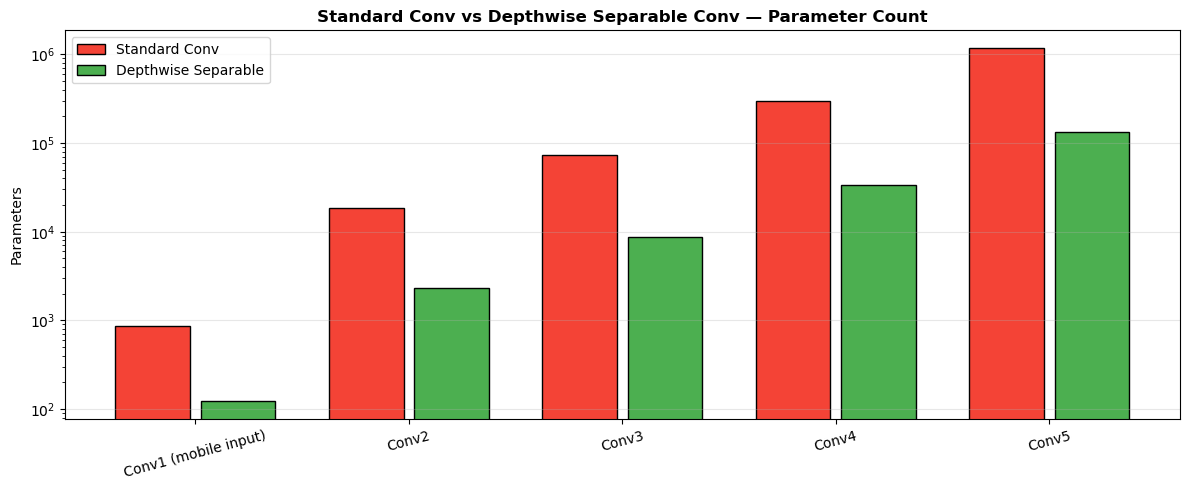

In [11]:
# Parameter and FLOP comparison: standard vs depthwise separable
def compare_convolutions(C_in, C_out, K, H, W):
    # Standard conv
    std_params = C_out * C_in * K * K
    std_flops  = std_params * H * W * 2   # multiply-accumulate = 2 ops

    # Depthwise + Pointwise
    dw_params  = C_in * K * K
    pw_params  = C_out * C_in * 1 * 1
    dw_flops   = C_in * K * K * H * W * 2
    pw_flops   = C_in * C_out * H * W * 2
    sep_params = dw_params + pw_params
    sep_flops  = dw_flops  + pw_flops

    return std_params, std_flops, sep_params, sep_flops


configs = [
    (3,  32,  3, 112, 112, 'Conv1 (mobile input)'),
    (32, 64,  3,  56,  56, 'Conv2'),
    (64, 128, 3,  28,  28, 'Conv3'),
    (128,256, 3,  14,  14, 'Conv4'),
    (256,512, 3,   7,   7, 'Conv5'),
]

print(f'{"Layer":<22} {"Std Params":>12} {"DS Params":>12} {"Ratio":>8}')
print('-' * 60)
total_std = total_sep = 0
for (ci, co, k, h, w, label) in configs:
    sp, sf, dp, df = compare_convolutions(ci, co, k, h, w)
    total_std += sp; total_sep += dp
    print(f'{label:<22} {sp:>12,} {dp:>12,} {sp/dp:>8.1f}×')
print('-' * 60)
print(f'{"TOTAL":<22} {total_std:>12,} {total_sep:>12,} {total_std/total_sep:>8.1f}×')

# Bar chart
labels = [c[5] for c in configs]
std_p  = [compare_convolutions(*c[:6-1])[0] for c in configs]
sep_p  = [compare_convolutions(*c[:6-1])[2] for c in configs]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, std_p, 0.35, label='Standard Conv', color='#F44336', edgecolor='black')
ax.bar(x + 0.2, sep_p, 0.35, label='Depthwise Separable', color='#4CAF50', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Parameters')
ax.set_yscale('log')
ax.set_title('Standard Conv vs Depthwise Separable Conv — Parameter Count', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
if TORCH:

    class DepthwiseSeparableConv(nn.Module):
        """Depthwise conv + BN + ReLU, then Pointwise (1×1) conv + BN + ReLU."""
        def __init__(self, in_ch, out_ch, stride=1):
            super().__init__()
            self.depthwise = nn.Sequential(
                nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1,
                          groups=in_ch, bias=False),   # groups=in_ch → one filter/channel
                nn.BatchNorm2d(in_ch),
                nn.ReLU6(inplace=True),
            )
            self.pointwise = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU6(inplace=True),
            )

        def forward(self, x):
            return self.pointwise(self.depthwise(x))


    class MiniMobileNet(nn.Module):
        """MobileNet-style network for CIFAR-10 (32×32)."""
        def __init__(self, num_classes=10, width_mult=1.0):
            super().__init__()
            def ch(c): return int(c * width_mult)

            self.net = nn.Sequential(
                nn.Conv2d(3, ch(32), 3, padding=1, bias=False),
                nn.BatchNorm2d(ch(32)), nn.ReLU6(inplace=True),

                DepthwiseSeparableConv(ch(32), ch(64)),
                DepthwiseSeparableConv(ch(64), ch(128), stride=2),
                DepthwiseSeparableConv(ch(128), ch(128)),
                DepthwiseSeparableConv(ch(128), ch(256), stride=2),
                DepthwiseSeparableConv(ch(256), ch(256)),

                nn.AdaptiveAvgPool2d(1),
            )
            self.fc = nn.Linear(ch(256), num_classes)

        def forward(self, x):
            x = self.net(x)
            return self.fc(x.flatten(1))


    mobile = MiniMobileNet()
    n_params = sum(p.numel() for p in mobile.parameters() if p.requires_grad)
    print(f'MiniMobileNet — Parameters: {n_params:,}')

    # Compare with a standard-conv equivalent
    class StandardConvNet(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
                nn.Conv2d(32, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
                nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
                nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(),
                nn.Conv2d(128, 256, 3, stride=2, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(),
                nn.Conv2d(256, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(),
                nn.AdaptiveAvgPool2d(1),
            )
            self.fc = nn.Linear(256, num_classes)
        def forward(self, x):
            return self.fc(self.net(x).flatten(1))

    std_net = StandardConvNet()
    n_std = sum(p.numel() for p in std_net.parameters() if p.requires_grad)
    print(f'Standard ConvNet (same depth) — Parameters: {n_std:,}')
    print(f'MobileNet is {n_std/n_params:.1f}× smaller')

MiniMobileNet — Parameters: 136,778
Standard ConvNet (same depth) — Parameters: 1,129,514
MobileNet is 8.3× smaller


## 7. Transfer Learning — Reusing Pre-trained Weights

Training a deep CNN from scratch requires **millions of labeled images** and **days of GPU time**.  
**Transfer learning** reuses features learned on large datasets (ImageNet) for new tasks.

### Two Strategies


 Strategy 1 — Feature Extraction: (All convolutional layers of a pre-trained model (e.g., ResNet) are "frozen." Only the final classification layer (Fully Connected) is discarded and replaced with a new layer suitable for your specific problem.)
```
   Pre-trained backbone (FROZEN — weights don't change)
     → extract features → new classification head (trained)
   Use when: small dataset, similar to source domain
```
 Strategy 2 — Fine-tuning: You unfreeze not just the last layer, but also the last few convolutional blocks of the network. This helps the model adapt better to the specific details in your own dataset.
```
   Pre-trained backbone (some layers UNFROZEN — low learning rate)
     → train end-to-end with new head
   Use when: medium dataset, or domain differs from ImageNet
```

### Why it works — hierarchical features
- **Early layers** (edges, textures) — universal, transfer to almost any task
- **Middle layers** (shapes, parts) — somewhat task-specific
- **Late layers / head** (semantic concepts) — very task-specific, always replace

Strategy 1 — Feature Extraction:
  Total parameters:     11,181,642
  Trainable parameters:      5,130  (only the new head)
  Frozen parameters:    11,176,512  (100.0% of network)

Strategy 2 — Fine-tuning (unfreeze layer3, layer4, head):
  Trainable parameters: 10,498,570  (93.9% of network)


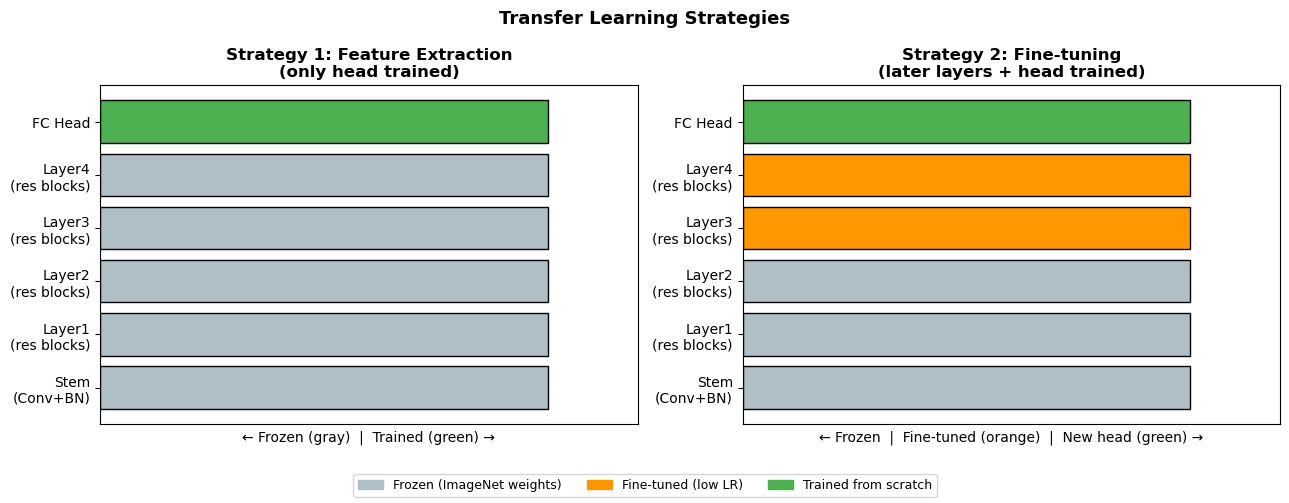

In [13]:
if TORCH:
    from torchvision.models import resnet18, ResNet18_Weights

    # ── Strategy 1: Feature Extraction (frozen backbone) ─────────────────────
    backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # Freeze ALL backbone parameters
    for param in backbone.parameters():
        param.requires_grad = False

    # Replace the final FC layer with our own (unfrozen by default)
    in_features = backbone.fc.in_features   # 512 for ResNet-18
    backbone.fc = nn.Linear(in_features, 10)   # CIFAR-10: 10 classes

    trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in backbone.parameters())
    print('Strategy 1 — Feature Extraction:')
    print(f'  Total parameters:     {total:>10,}')
    print(f'  Trainable parameters: {trainable:>10,}  (only the new head)')
    print(f'  Frozen parameters:    {total-trainable:>10,}  ({100*(total-trainable)/total:.1f}% of network)')

    # ── Strategy 2: Fine-tuning (unfreeze some layers) ────────────────────────
    backbone2 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # Freeze early layers (stem + layer1 + layer2)
    for name, param in backbone2.named_parameters():
        if any(name.startswith(p) for p in ['conv1','bn1','layer1','layer2']):
            param.requires_grad = False

    # Replace head
    backbone2.fc = nn.Linear(backbone2.fc.in_features, 10)

    trainable2 = sum(p.numel() for p in backbone2.parameters() if p.requires_grad)
    frozen2    = total - trainable2 + backbone2.fc.weight.numel() + backbone2.fc.bias.numel()

    print('\nStrategy 2 — Fine-tuning (unfreeze layer3, layer4, head):')
    print(f'  Trainable parameters: {trainable2:>10,}  ({100*trainable2/total:.1f}% of network)')

    # Visualise training strategy
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    layers = ['Stem\n(Conv+BN)', 'Layer1\n(res blocks)', 'Layer2\n(res blocks)',
              'Layer3\n(res blocks)', 'Layer4\n(res blocks)', 'FC Head']
    # Strategy 1
    colors1 = ['#B0BEC5'] * 5 + ['#4CAF50']
    axes[0].barh(layers, [1]*6, color=colors1, edgecolor='black')
    axes[0].set_title('Strategy 1: Feature Extraction\n(only head trained)', fontweight='bold')
    axes[0].set_xlabel('← Frozen (gray)  |  Trained (green) →')

    # Strategy 2
    colors2 = ['#B0BEC5'] * 3 + ['#FF9800', '#FF9800', '#4CAF50']
    axes[1].barh(layers, [1]*6, color=colors2, edgecolor='black')
    axes[1].set_title('Strategy 2: Fine-tuning\n(later layers + head trained)', fontweight='bold')
    axes[1].set_xlabel('← Frozen  |  Fine-tuned (orange)  |  New head (green) →')

    for ax in axes:
        ax.set_xlim(0, 1.2); ax.set_xticks([])

    legend = [
        mpatches.Patch(color='#B0BEC5', label='Frozen (ImageNet weights)'),
        mpatches.Patch(color='#FF9800', label='Fine-tuned (low LR)'),
        mpatches.Patch(color='#4CAF50', label='Trained from scratch'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9)
    plt.suptitle('Transfer Learning Strategies', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()
else:
    print('Skipping — PyTorch not available.')

In [14]:
if TORCH:
    # Practical tip: use different learning rates for backbone vs head
    backbone3 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    backbone3.fc = nn.Linear(backbone3.fc.in_features, 10)

    optimizer = optim.Adam([
        {'params': backbone3.layer3.parameters(),  'lr': 1e-4},   # low LR for earlier layers
        {'params': backbone3.layer4.parameters(),  'lr': 1e-4},
        {'params': backbone3.fc.parameters(),      'lr': 1e-3},   # higher LR for new head
    ])

    print('Differential learning rates for fine-tuning:')
    for group in optimizer.param_groups:
        n = sum(p.numel() for p in group['params'])
        print(f"  LR = {group['lr']:.0e}  |  {n:>10,} params")

    print('\nKey rule: backbone layers get 10x lower LR than the head.')
    print('This preserves learned ImageNet features while adapting to the new task.')

Differential learning rates for fine-tuning:
  LR = 1e-04  |   2,099,712 params
  LR = 1e-04  |   8,393,728 params
  LR = 1e-03  |       5,130 params

Key rule: backbone layers get 10x lower LR than the head.
This preserves learned ImageNet features while adapting to the new task.


## 8. Squeeze-and-Excitation (SE) Blocks — Channel Attention

**Momenta / Oxford, 2018** — Won ILSVRC 2017 with **2.25%** top-5 error

### The Idea: Let the Network Decide Which Channels Matter
Standard convolution operations combine spatial information but fail to fully capture the global relationships between channels. The SE block allows the network to decide which feature (e.g., the "wheel" feature or the "background" feature) is more critical for the current prediction.

Not all feature maps (channels) are equally important for every input.  
An SE block learns to **recalibrate channel-wise responses** adaptively:

```
  Feature maps  (C×H×W)
       │
  Global Average Pool  →  (C×1×1)   ← "Squeeze": summarise spatial info
       │
  FC(C → C/r) → ReLU  →  (C/r)     ← "Excitation": learn inter-channel relationships
       │
  FC(C/r → C) → Sigmoid  →  (C)    ← channel attention weights ∈ [0, 1]
       │
  Scale original feature maps by attention weights
  (multiply each channel by its learned importance score)
```

SE blocks are **plug-and-play** — they can be inserted into any CNN block with minimal extra parameters.  
SENet adds them to every ResNet block: SE-ResNet-50 improves top-1 accuracy by **~1.4%** on ImageNet with only **~10%** more parameters.

SE Block demo:
  Input:  (1, 64, 8, 8)
  Output: (1, 64, 8, 8)  (same shape, channels re-weighted)


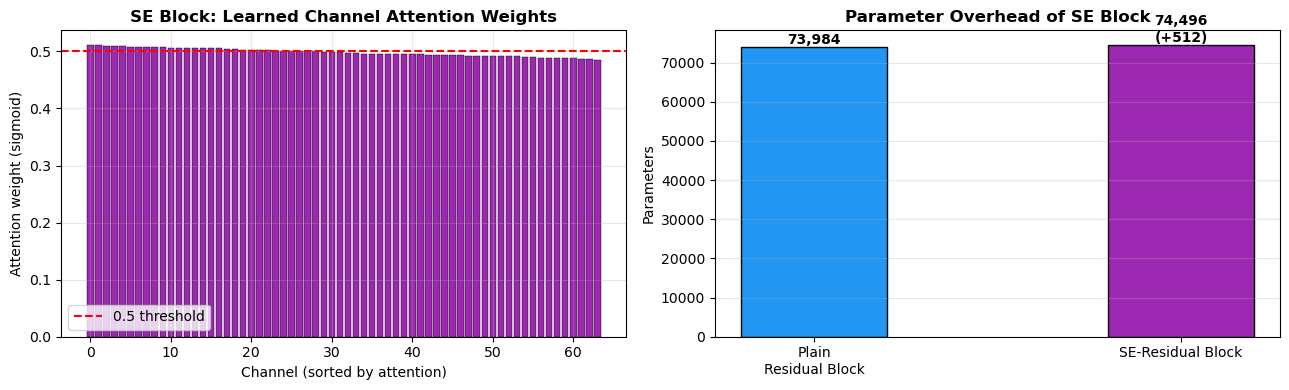


SE block overhead: 0.7% extra parameters for ~1.4% ImageNet accuracy gain


In [15]:
if TORCH:

    class SEBlock(nn.Module):
        """
        Squeeze-and-Excitation block.
        ratio: channel reduction ratio in the FC bottleneck.
        """
        def __init__(self, channels, ratio=16):
            super().__init__()
            self.squeeze   = nn.AdaptiveAvgPool2d(1)     # (C, H, W) → (C, 1, 1)
            self.excitation = nn.Sequential(
                nn.Flatten(),
                nn.Linear(channels, channels // ratio, bias=False),
                nn.ReLU(inplace=True),
                nn.Linear(channels // ratio, channels, bias=False),
                nn.Sigmoid(),                             # outputs ∈ [0, 1]
            )

        def forward(self, x):
            b, c, h, w = x.shape
            # Squeeze: global info per channel
            s = self.squeeze(x)           # (B, C, 1, 1)
            # Excitation: learn channel weights
            e = self.excitation(s)        # (B, C)
            e = e.view(b, c, 1, 1)       # reshape for broadcasting
            # Scale: re-weight each channel
            return x * e                  # element-wise scaling


    class SEResidualBlock(nn.Module):
        """Residual block with SE attention — the SE-ResNet building block."""
        def __init__(self, channels, ratio=16):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv2d(channels, channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(channels, channels, 3, padding=1, bias=False),
                nn.BatchNorm2d(channels),
            )
            self.se = SEBlock(channels, ratio)

        def forward(self, x):
            residual = x
            out = self.conv(x)
            out = self.se(out)        # ← apply channel attention BEFORE adding skip
            return F.relu(out + residual)


    # Demo: how SE block re-weights channels
    torch.manual_seed(42)
    se = SEBlock(channels=64, ratio=16)
    x_demo = torch.randn(1, 64, 8, 8)
    out_demo = se(x_demo)

    print('SE Block demo:')
    print(f'  Input:  {tuple(x_demo.shape)}')
    print(f'  Output: {tuple(out_demo.shape)}  (same shape, channels re-weighted)')

    # Extract and visualise attention weights
    with torch.no_grad():
        sq  = se.squeeze(x_demo)
        att = se.excitation(sq).squeeze().numpy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.bar(range(64), sorted(att, reverse=True), color='#9C27B0', edgecolor='black', lw=0.3)
    ax1.axhline(0.5, color='red', linestyle='--', lw=1.5, label='0.5 threshold')
    ax1.set_xlabel('Channel (sorted by attention)')
    ax1.set_ylabel('Attention weight (sigmoid)')
    ax1.set_title('SE Block: Learned Channel Attention Weights', fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Compare plain ResBlock vs SE-ResBlock
    plain = ResidualBlock(64, 64)
    se_block = SEResidualBlock(64)
    p_plain = sum(p.numel() for p in plain.parameters())
    p_se    = sum(p.numel() for p in se_block.parameters())

    ax2.bar(['Plain\nResidual Block', 'SE-Residual Block'],
            [p_plain, p_se], color=['#2196F3', '#9C27B0'], edgecolor='black', width=0.4)
    for i, (v, label) in enumerate(zip([p_plain, p_se], [f'{p_plain:,}', f'{p_se:,}\n(+{(p_se-p_plain):,})'])):
        ax2.text(i, v + 100, label, ha='center', va='bottom', fontweight='bold')
    ax2.set_ylabel('Parameters')
    ax2.set_title('Parameter Overhead of SE Block', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    overhead = (p_se - p_plain) / p_plain * 100
    print(f'\nSE block overhead: {overhead:.1f}% extra parameters for ~1.4% ImageNet accuracy gain')

## 9. Training CIFAR-10: Comparing All Architectures

We now train all four architectures side-by-side on **CIFAR-10** (60,000 color images, 10 classes) to compare their accuracy, speed, and parameter counts in a fair experiment.

Train: 50,000 samples | Test: 10,000 samples
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


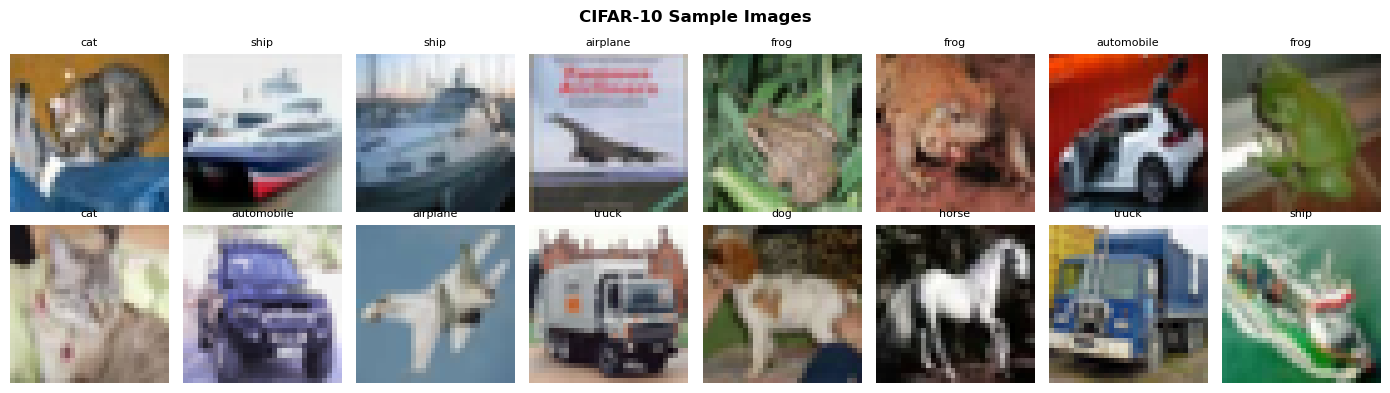

In [16]:
if TORCH:
    # ── CIFAR-10 dataset ─────────────────────────────────────────────────────
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010)),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010)),
    ])

    train_dataset = datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
    test_dataset  = datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)
    train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0, pin_memory=True)
    test_loader   = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

    classes = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

    print(f'Train: {len(train_dataset):,} samples | Test: {len(test_dataset):,} samples')
    print(f'Classes: {classes}')

    # Visualise a batch
    imgs, labels = next(iter(test_loader))
    imgs = imgs[:16]
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    imgs_show = (imgs * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs_show[i].permute(1,2,0).numpy())
        ax.set_title(classes[labels[i]], fontsize=8)
        ax.axis('off')
    plt.suptitle('CIFAR-10 Sample Images', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [17]:
if TORCH:

    def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3, name=''):
        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}

        for epoch in range(1, epochs + 1):
            # Train
            model.train()
            tr_loss = tr_correct = 0
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X), y)
                loss.backward()
                optimizer.step()
                tr_loss    += loss.item() * len(y)
                tr_correct += (model(X).argmax(1) == y).sum().item()
            scheduler.step()

            # Eval
            model.eval()
            va_loss = va_correct = 0
            with torch.no_grad():
                for X, y in test_loader:
                    X, y = X.to(device), y.to(device)
                    logits = model(X)
                    va_loss    += criterion(logits, y).item() * len(y)
                    va_correct += (logits.argmax(1) == y).sum().item()

            history['train_acc'].append(tr_correct / len(train_loader.dataset) * 100)
            history['val_acc'].append(va_correct  / len(test_loader.dataset)  * 100)
            history['train_loss'].append(tr_loss / len(train_loader.dataset))
            history['val_loss'].append(va_loss   / len(test_loader.dataset))

            if epoch % 5 == 0 or epoch == 1:
                print(f'  [{name}] Ep {epoch:>2}/{epochs} | '
                      f'Train {history["train_acc"][-1]:.1f}% | '
                      f'Val {history["val_acc"][-1]:.1f}%')

        return history, model


    EPOCHS = 15
    results = {}

    for name, ModelClass in [
        ('MiniVGG',      lambda: MiniVGG(10)),
        ('ResNet',       lambda: ResNet(10)),
        ('MiniInception',lambda: MiniInception(10)),
        ('MobileNet',    lambda: MiniMobileNet(10)),
    ]:
        print(f'\nTraining {name}...')
        model_inst = ModelClass()
        n_p = sum(p.numel() for p in model_inst.parameters() if p.requires_grad)
        print(f'  Parameters: {n_p:,}')
        hist, trained = train_model(model_inst, train_loader, test_loader,
                                    epochs=EPOCHS, name=name)
        results[name] = {'history': hist, 'params': n_p, 'model': trained}


Training MiniVGG...
  Parameters: 815,018
  [MiniVGG] Ep  1/15 | Train 44.7% | Val 58.8%
  [MiniVGG] Ep  5/15 | Train 75.5% | Val 77.7%
  [MiniVGG] Ep 10/15 | Train 83.4% | Val 84.6%
  [MiniVGG] Ep 15/15 | Train 86.3% | Val 86.0%

Training ResNet...
  Parameters: 2,777,674
  [ResNet] Ep  1/15 | Train 50.9% | Val 58.9%
  [ResNet] Ep  5/15 | Train 83.3% | Val 79.9%
  [ResNet] Ep 10/15 | Train 91.4% | Val 86.8%
  [ResNet] Ep 15/15 | Train 95.2% | Val 90.3%

Training MiniInception...
  Parameters: 80,066
  [MiniInception] Ep  1/15 | Train 45.8% | Val 51.0%
  [MiniInception] Ep  5/15 | Train 69.3% | Val 66.3%
  [MiniInception] Ep 10/15 | Train 76.0% | Val 73.1%
  [MiniInception] Ep 15/15 | Train 78.3% | Val 76.0%

Training MobileNet...
  Parameters: 136,778
  [MobileNet] Ep  1/15 | Train 47.8% | Val 56.7%
  [MobileNet] Ep  5/15 | Train 76.8% | Val 75.6%
  [MobileNet] Ep 10/15 | Train 83.3% | Val 81.2%
  [MobileNet] Ep 15/15 | Train 85.2% | Val 82.6%


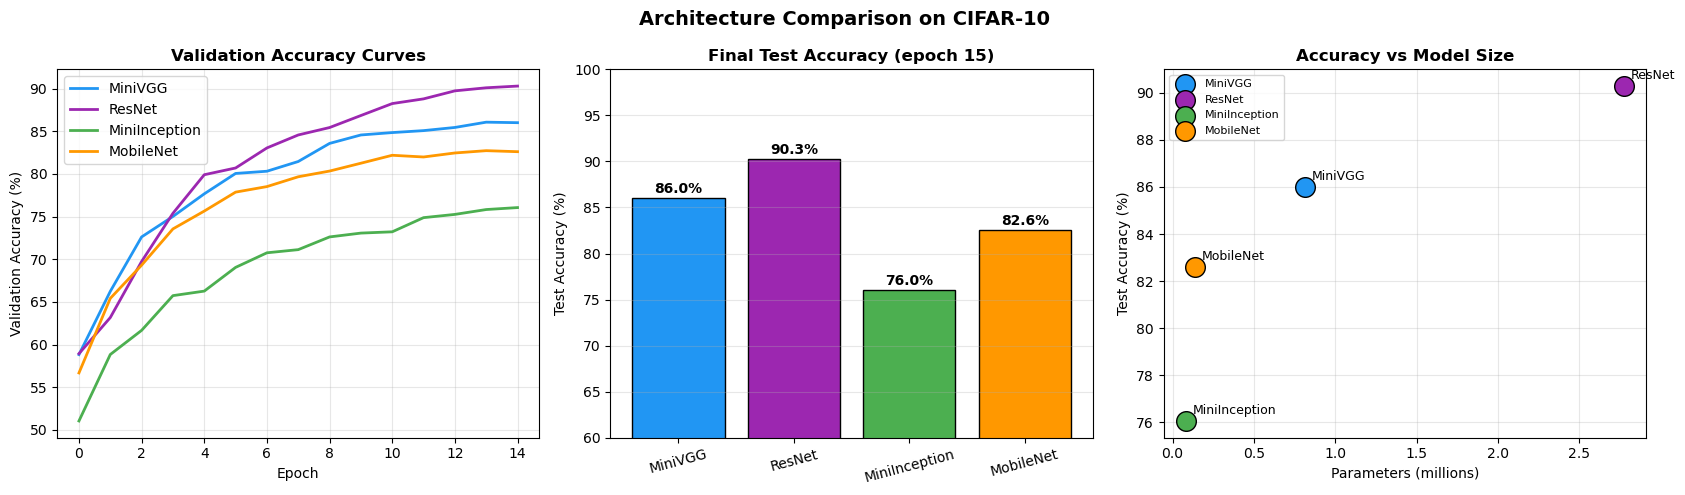


Architecture       Parameters   Test Acc
------------------------------------------
ResNet              2,777,674      90.3%
MiniVGG               815,018      86.0%
MobileNet             136,778      82.6%
MiniInception          80,066      76.0%


In [18]:
if TORCH and results:

    palette = {'MiniVGG': '#2196F3', 'ResNet': '#9C27B0',
               'MiniInception': '#4CAF50', 'MobileNet': '#FF9800'}

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── Training curves ───────────────────────────────────────────────────────
    for name, res in results.items():
        hist = res['history']
        axes[0].plot(hist['val_acc'], label=name, color=palette[name], lw=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Accuracy (%)')
    axes[0].set_title('Validation Accuracy Curves', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # ── Final accuracy bar chart ──────────────────────────────────────────────
    names = list(results.keys())
    final_accs = [results[n]['history']['val_acc'][-1] for n in names]
    bars = axes[1].bar(names, final_accs,
                       color=[palette[n] for n in names], edgecolor='black')
    for bar, acc in zip(bars, final_accs):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
    axes[1].set_ylim(60, 100); axes[1].set_ylabel('Test Accuracy (%)')
    axes[1].set_title(f'Final Test Accuracy (epoch {EPOCHS})', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].grid(axis='y', alpha=0.3)

    # ── Accuracy vs parameters ────────────────────────────────────────────────
    for name in names:
        acc = results[name]['history']['val_acc'][-1]
        params = results[name]['params']
        axes[2].scatter(params / 1e6, acc, s=200, color=palette[name],
                        edgecolors='black', zorder=3, label=name)
        axes[2].annotate(name, (params / 1e6, acc), textcoords='offset points',
                         xytext=(5, 5), fontsize=9)
    axes[2].set_xlabel('Parameters (millions)')
    axes[2].set_ylabel('Test Accuracy (%)')
    axes[2].set_title('Accuracy vs Model Size', fontweight='bold')
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    plt.suptitle('Architecture Comparison on CIFAR-10', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary table
    print(f"\n{'Architecture':<16} {'Parameters':>12} {'Test Acc':>10}")
    print('-' * 42)
    for name in sorted(names, key=lambda n: results[n]['history']['val_acc'][-1], reverse=True):
        acc = results[name]['history']['val_acc'][-1]
        params = results[name]['params']
        print(f'{name:<16} {params:>12,} {acc:>9.1f}%')

## 10. Modern Architecture Design Principles

### What We've Learned from Each Architecture

| Architecture | Key Innovation | Lesson |
|---|---|---|
| **AlexNet** | Deep CNN + ReLU + Dropout | Depth matters for ImageNet-scale tasks |
| **VGGNet** | 3×3 filters stacked | Small filters are more efficient & expressive |
| **GoogLeNet** | Inception module | Multi-scale features in parallel |
| **ResNet** | Skip connections | Depth ≠ degradation if we learn residuals |
| **DenseNet** | Dense connections | Maximum feature reuse, fewer parameters |
| **MobileNet** | Depthwise separable | Efficiency: separate spatial & channel mixing |
| **SENet** | Channel attention | Learn which features matter most per input |

### EfficientNet — Principled Scaling

**Google Brain, 2019** showed that scaling **width, depth, and resolution** together in a fixed ratio yields the best accuracy/compute tradeoff — the **compound scaling** rule:

```
  depth    ∝  φ^α
  width    ∝  φ^β     where φ = available compute budget
  resolution ∝ φ^γ

  Constraint: α·β²·γ² ≈ 2  (doubles FLOPs per step)
```

EfficientNet-B7 achieves **84.3% ImageNet top-1** — matching ensembles of 2019's best networks.

### What Comes Next? Vision Transformers (ViT)

In 2020, the **Vision Transformer (ViT)** applied the transformer self-attention mechanism to image patches — achieving state-of-the-art with **no convolutions at all** on large datasets.  
**ConvNeXt (2022)** responded by modernizing ResNet with transformer-style design choices, closing the gap.

The field is now a rich interplay between convolutional and attention-based approaches.

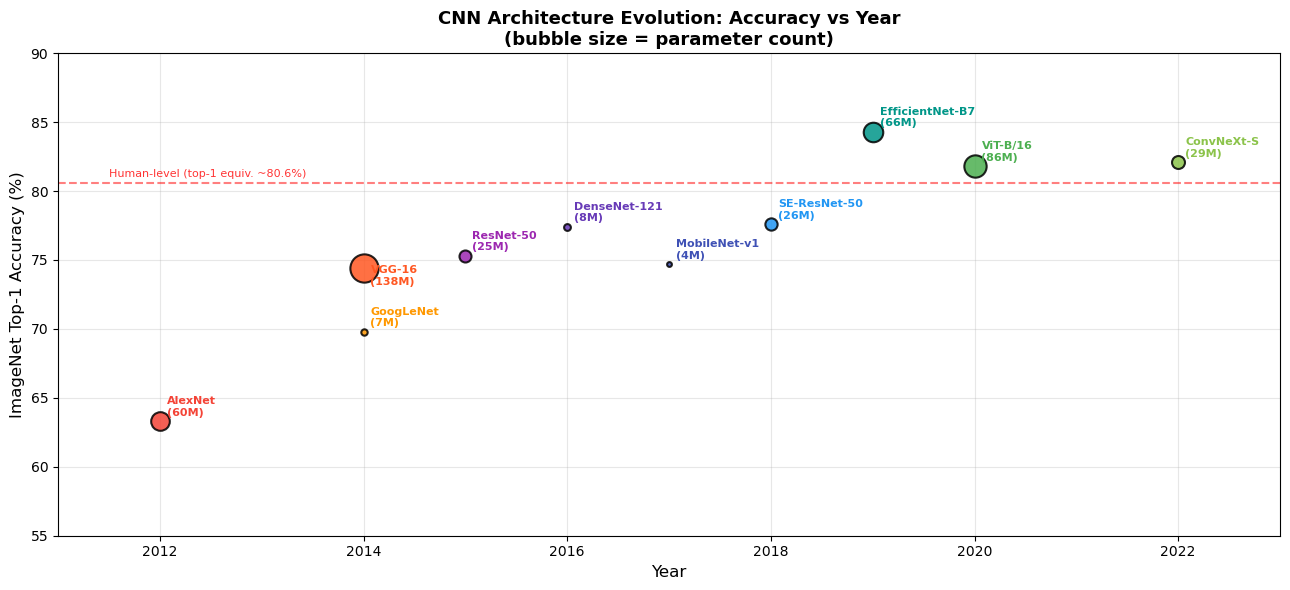

In [19]:
# Visualise the full evolution: accuracy vs year vs efficiency
arch_data = [
    # (year, top1_imagenet, params_M, name, color)
    (2012, 63.3,  60,   'AlexNet',        '#F44336'),
    (2014, 74.4, 138,   'VGG-16',         '#FF5722'),
    (2014, 69.8,   7,   'GoogLeNet',      '#FF9800'),
    (2015, 75.3,  25,   'ResNet-50',      '#9C27B0'),
    (2016, 77.4,   8,   'DenseNet-121',   '#673AB7'),
    (2017, 74.7,   4,   'MobileNet-v1',   '#3F51B5'),
    (2018, 77.6,  26,   'SE-ResNet-50',   '#2196F3'),
    (2019, 84.3,  66,   'EfficientNet-B7','#009688'),
    (2020, 81.8,  86,   'ViT-B/16',       '#4CAF50'),
    (2022, 82.1,  29,   'ConvNeXt-S',     '#8BC34A'),
]

fig, ax = plt.subplots(figsize=(13, 6))

for (year, acc, params, name, color) in arch_data:
    scatter = ax.scatter(year, acc, s=params * 3, color=color,
                          edgecolors='black', lw=1.5, alpha=0.85, zorder=3)
    offset = (5, 4) if name not in ['VGG-16'] else (5, -12)
    ax.annotate(f'{name}\n({params}M)', (year, acc),
                textcoords='offset points', xytext=offset,
                fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('ImageNet Top-1 Accuracy (%)', fontsize=12)
ax.set_title('CNN Architecture Evolution: Accuracy vs Year\n(bubble size = parameter count)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(55, 90)
ax.set_xlim(2011, 2023)

# Add "human level" line
ax.axhline(80.6, color='red', linestyle='--', alpha=0.5, lw=1.5)
ax.text(2011.5, 81.0, 'Human-level (top-1 equiv. ~80.6%)', fontsize=8, color='red', alpha=0.8)

plt.tight_layout()
plt.show()

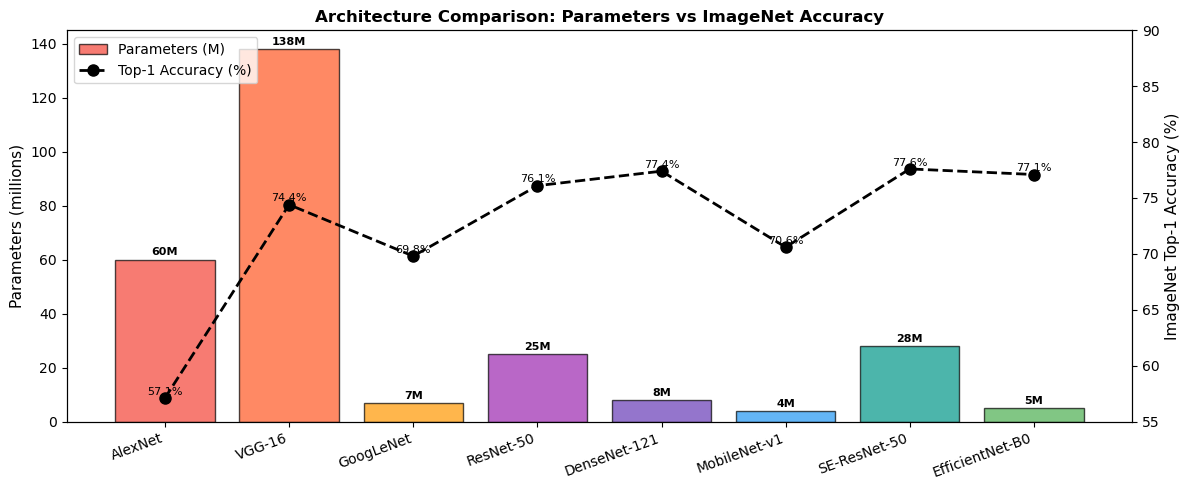

Efficiency note: MobileNet and EfficientNet-B0 achieve competitive accuracy
with 10-30× fewer parameters than VGG — crucial for real-world deployment.


In [20]:
# Architecture complexity comparison (parameters vs FLOPs proxy)
summary_data = [
    ('AlexNet',          60,  0.7, 57.1,  '#F44336'),
    ('VGG-16',          138,  1.0, 74.4,  '#FF5722'),
    ('GoogLeNet',         7,  0.09, 69.8, '#FF9800'),
    ('ResNet-50',        25,  0.25, 76.1, '#9C27B0'),
    ('DenseNet-121',      8,  0.18, 77.4, '#673AB7'),
    ('MobileNet-v1',      4,  0.04, 70.6, '#2196F3'),
    ('SE-ResNet-50',     28,  0.26, 77.6, '#009688'),
    ('EfficientNet-B0',   5,  0.04, 77.1, '#4CAF50'),
]

fig, ax = plt.subplots(figsize=(12, 5))

names   = [d[0] for d in summary_data]
params  = [d[1] for d in summary_data]
accs    = [d[3] for d in summary_data]
cols    = [d[4] for d in summary_data]

x = np.arange(len(names))
ax2 = ax.twinx()

bars = ax.bar(x, params, color=cols, edgecolor='black', alpha=0.7, label='Parameters (M)')
ax2.plot(x, accs, 'k--o', lw=2, markersize=8, label='Top-1 Accuracy (%)')

ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_ylabel('Parameters (millions)', fontsize=11)
ax2.set_ylabel('ImageNet Top-1 Accuracy (%)', fontsize=11)
ax2.set_ylim(55, 90)

for xi, (p, a) in enumerate(zip(params, accs)):
    ax.text(xi, p + 1.5, f'{p}M', ha='center', fontsize=8, fontweight='bold')
    ax2.text(xi, a + 0.3, f'{a}%', ha='center', fontsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax.set_title('Architecture Comparison: Parameters vs ImageNet Accuracy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Efficiency note: MobileNet and EfficientNet-B0 achieve competitive accuracy')
print('with 10-30× fewer parameters than VGG — crucial for real-world deployment.')

## 11. Practical Cheat Sheet — Which Architecture to Use?

| Scenario | Recommended Architecture | Reason |
|---|---|---|
| **Learning / prototyping** | MiniVGG or custom CNN | Simple, easy to understand and debug |
| **General vision task, full compute** | ResNet-50 or ResNet-101 | Battle-tested, strong baseline |
| **Mobile / embedded / real-time** | MobileNetV2 or EfficientNet-B0 | Low parameters, fast inference |
| **Small labeled dataset (<10k)** | Transfer learning (ResNet/EfficientNet) | Reuse ImageNet features |
| **Large dataset, custom domain** | Fine-tune last 2 blocks | Balance between reuse and adaptation |
| **Multi-scale objects (detection)** | FPN + ResNet backbone | Feature Pyramid Network handles scales |
| **State of the art (2024+)** | ConvNeXt-v2 or DINOv2 | Best accuracy/compute tradeoffs |

---

### Rule of Thumb for Transfer Learning

```
 Dataset size    Domain similarity     Strategy
 ──────────────  ────────────────────  ──────────────────────────────────
 Small           Similar               Feature extraction (freeze all)
 Small           Different             Fine-tune top layers only
 Large           Similar               Fine-tune more layers
 Large           Different             Train from scratch or fine-tune all
```

---

## Summary

| Architecture | Innovation | Key Technique | Typical Params |
|---|---|---|---|
| **VGGNet** | Very deep, simple | Stack 3×3 convolutions | 138M |
| **ResNet** | Skip connections | `F(x) + x` residual | 25M (50-layer) |
| **GoogLeNet** | Multi-scale | Inception module | 7M |
| **DenseNet** | Dense reuse | Concatenate all layers | 8M |
| **MobileNet** | Efficiency | Depthwise separable conv | 4M |
| **SENet** | Attention | Channel recalibration | +10% overhead |
| **EfficientNet** | Scaling law | Compound depth/width/res | 5–66M |

---
**Next notebook →** Object Detection & Semantic Segmentation — from image classification to localizing and labeling every pixel with YOLO, SSD, and U-Net.